***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [9. 实践部分](9_1_visualisation-inspection.ipynb)
    * 下一节： [9.2 基础校准流程](9_2_calibration_workflow.ipynb)

***


导入标准模块:


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

STYLE_PATH = Path("../style/course.css")
TOGGLE_PATH = Path("../style/code_toggle.html")

if HTML is not None and display is not None:
    if STYLE_PATH.exists():
        display(HTML(f"<style>{STYLE_PATH.read_text(encoding='utf-8')}</style>"))
    if TOGGLE_PATH.exists():
        display(HTML(TOGGLE_PATH.read_text(encoding="utf-8")))

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.default_rng(20260421)


## 实践 01：数据检查、可视化与初步质量控制

到了第 9 章，我们不再把重点放在单独的理论概念，而是把前面各章的内容串成一条实际的数据处理主线。一个稳健的连续谱处理流程通常至少包含六步：

1. 先看懂观测结构与元数据；
2. 再识别明显异常与应当 flag 的数据；
3. 用校准源建立 bandpass、gain 和 flux 标尺；
4. 把校准解转移到目标场；
5. 做基础成像与必要的自校准；
6. 最后做图像质量评估与科学测量。

这一节对应其中的前两步。重点不是“记住某个软件按钮”，而是建立一个专业习惯：在开始求解之前，先确认你到底拿到了一份什么样的数据，以及它已经暴露出了哪些问题。


***


### 9.1.1 一个可复现的“合成测量集”

真实的 Measurement Set 往往需要 CASA 或其他软件环境才能完整浏览。为了让 notebook 自身可以直接运行，这里我们构造一个“小型合成测量集”，保留最关键的几类信息：

- 阵列布局与 $uv$ 覆盖；
- 多个时间采样与多个频率通道；
- 一个含有中心亮源和离轴弱源的天空模型；
- 一段注入了 RFI 的频率区间；
- 一组由单天线异常导致的坏基线数据。

这并不是为了取代真实软件，而是为了让你在一个完全可执行的环境里练习“怎么看出问题”。


In [2]:
def baseline_pairs(nant):
    return [(p, q) for p in range(nant) for q in range(p + 1, nant)]


def uv_tracks(ant_xy_m, hour_angle_h, dec_deg, wavelength_m=0.214):
    pairs = baseline_pairs(len(ant_xy_m))
    hour_angle_rad = np.deg2rad(15.0 * hour_angle_h)
    dec = np.deg2rad(dec_deg)
    u = np.zeros((hour_angle_h.size, len(pairs)))
    v = np.zeros_like(u)

    for ti, ha in enumerate(hour_angle_rad):
        for bi, (p, q) in enumerate(pairs):
            dx = (ant_xy_m[q, 0] - ant_xy_m[p, 0]) / wavelength_m
            dy = (ant_xy_m[q, 1] - ant_xy_m[p, 1]) / wavelength_m
            u[ti, bi] = dx * np.sin(ha) + dy * np.cos(ha)
            v[ti, bi] = -dx * np.sin(dec) * np.cos(ha) + dy * np.sin(dec) * np.sin(ha)
    return pairs, u, v


def point_source_visibilities(u, v, freqs_ghz, sources):
    vis = np.zeros(u.shape + (freqs_ghz.size,), dtype=complex)
    ref_freq = np.median(freqs_ghz)
    for flux0, l_src, m_src, alpha in sources:
        spectrum = flux0 * (freqs_ghz / ref_freq) ** alpha
        phase = np.exp(-2j * np.pi * (u[..., None] * l_src + v[..., None] * m_src))
        vis += phase * spectrum[None, None, :]
    return vis


def simulate_measurement_set():
    ant_xy_m = np.array(
        [
            [0.0, 0.0],
            [38.0, 18.0],
            [116.0, -24.0],
            [208.0, 44.0],
            [330.0, -36.0],
            [472.0, 10.0],
        ]
    )
    times_h = np.linspace(-4.0, 4.0, 72)
    freqs_ghz = np.linspace(1.10, 1.90, 64)
    pairs, u, v = uv_tracks(ant_xy_m, times_h, dec_deg=45.0, wavelength_m=0.214)

    sky = [
        (1.0, 0.0, 0.0, -0.7),
        (0.24, 0.035, -0.018, -0.9),
        (0.12, -0.048, 0.024, -0.5),
    ]
    model = point_source_visibilities(u, v, freqs_ghz, sky)

    ntime = times_h.size
    nchan = freqs_ghz.size
    nant = ant_xy_m.shape[0]

    chan = np.linspace(-1.0, 1.0, nchan)
    bandpass_amp = 1.0 + 0.04 * chan[None, :] * np.linspace(-1.0, 1.0, nant)[:, None]
    bandpass_phase = 0.10 * np.sin(np.pi * chan)[None, :] * np.linspace(0.2, 1.0, nant)[:, None]
    bandpass = bandpass_amp * np.exp(1j * bandpass_phase)

    ant_phase = np.linspace(0.0, np.pi, nant, endpoint=False)
    time_amp = 1.0 + 0.03 * np.sin(0.8 * times_h[:, None] + ant_phase[None, :])
    time_phase = 0.20 * np.sin(1.5 * times_h[:, None] + 0.6 * ant_phase[None, :])
    time_gain = time_amp * np.exp(1j * time_phase)

    data = np.zeros_like(model, dtype=complex)
    for bi, (p, q) in enumerate(pairs):
        lhs = time_gain[:, p, None] * bandpass[p][None, :]
        rhs = np.conj(time_gain[:, q, None] * bandpass[q][None, :])
        data[:, bi, :] = lhs * model[:, bi, :] * rhs

    data += 0.02 * (
        RNG.normal(size=data.shape) + 1j * RNG.normal(size=data.shape)
    )

    # Inject a short, strong RFI burst over a few channels.
    data[22:34, :, 12:16] += 1.4 * (
        RNG.normal(size=(12, len(pairs), 4)) + 1j * RNG.normal(size=(12, len(pairs), 4))
    )

    # Simulate one problematic antenna that loses gain for a subset of scans.
    bad_ant = 4
    bad_scans = slice(45, 55)
    for bi, (p, q) in enumerate(pairs):
        if p == bad_ant or q == bad_ant:
            data[bad_scans, bi, :] *= 0.35 * np.exp(1j * 0.6)

    return {
        "ant_xy_m": ant_xy_m,
        "times_h": times_h,
        "freqs_ghz": freqs_ghz,
        "pairs": pairs,
        "u": u,
        "v": v,
        "model": model,
        "data": data,
        "bad_ant": bad_ant,
    }


ms = simulate_measurement_set()
ntime, nbase, nchan = ms["data"].shape
nant = ms["ant_xy_m"].shape[0]
print(f"天线数 = {nant}，基线数 = {nbase}，积分数 = {ntime}，频率通道数 = {nchan}")


天线数 = 6，基线数 = 15，积分数 = 72，频率通道数 = 64


### 9.1.2 像 `listobs` 一样先看懂观测结构

开始处理前，至少要回答下面这些问题：

- 一共用了多少面天线、多少条基线？
- 时间采样和频率覆盖是否满足你的科学目标？
- $uv$ 覆盖是否足以支撑所需的成像分辨率与保真度？
- 观测中是否已经出现非常可疑的扫描、天线或通道？

下面的图模仿的是 `listobs`、`plotants` 和 `plotms` 的早期巡检习惯。


时间覆盖：-4.0 h 到 4.0 h
频率覆盖：1.10 GHz 到 1.90 GHz
最长物理基线：472.1 m


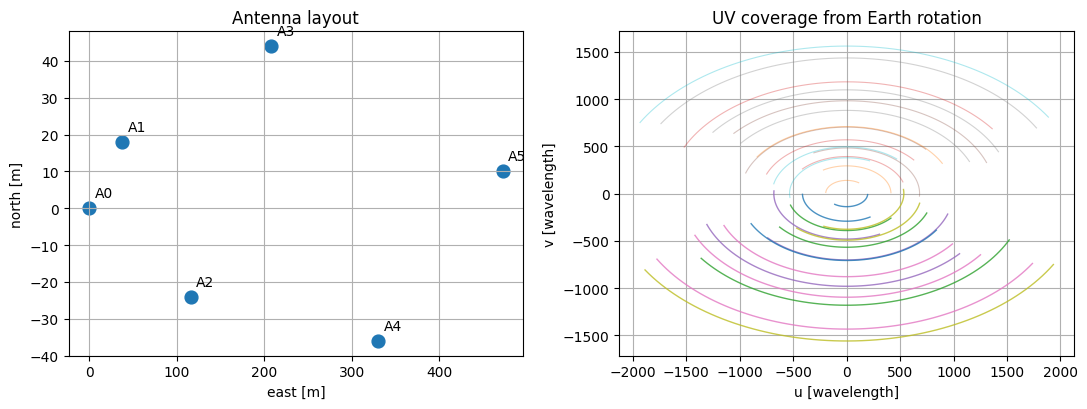

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].scatter(ms["ant_xy_m"][:, 0], ms["ant_xy_m"][:, 1], s=85, color="tab:blue")
for ant, (x, y) in enumerate(ms["ant_xy_m"]):
    axes[0].text(x + 6.0, y + 3.0, f"A{ant}", fontsize=10)
axes[0].set_xlabel("east [m]")
axes[0].set_ylabel("north [m]")
axes[0].set_title("Antenna layout")

for bi in range(ms["u"].shape[1]):
    axes[1].plot(ms["u"][:, bi], ms["v"][:, bi], lw=1.0, alpha=0.8)
    axes[1].plot(-ms["u"][:, bi], -ms["v"][:, bi], lw=0.8, alpha=0.35)
axes[1].set_xlabel("u [wavelength]")
axes[1].set_ylabel("v [wavelength]")
axes[1].set_title("UV coverage from Earth rotation")

plt.tight_layout()

longest_baseline = 0.0
for p, q in ms["pairs"]:
    dx, dy = ms["ant_xy_m"][q] - ms["ant_xy_m"][p]
    longest_baseline = max(longest_baseline, np.sqrt(dx**2 + dy**2))

print(f"时间覆盖：{ms['times_h'][0]:.1f} h 到 {ms['times_h'][-1]:.1f} h")
print(f"频率覆盖：{ms['freqs_ghz'][0]:.2f} GHz 到 {ms['freqs_ghz'][-1]:.2f} GHz")
print(f"最长物理基线：{longest_baseline:.1f} m")


只看阵列几何还不够。真正的问题往往藏在“振幅随时间或频率的异常结构”里。因此下一步通常要看：

- 按时间展开的振幅与相位；
- 按频率展开的平均 bandpass 形状；
- 动态谱或时频图中是否有窄带、宽带或脉冲式干扰。


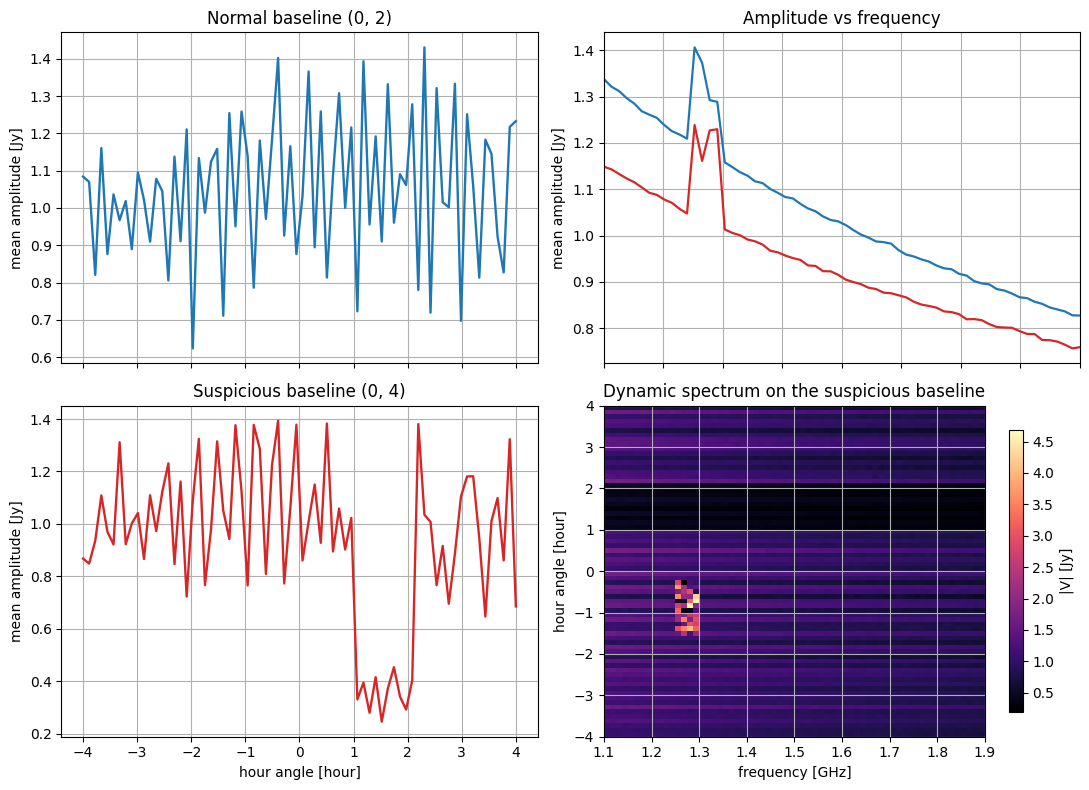

In [4]:
amp = np.abs(ms["data"])
good_baseline = ms["pairs"].index((0, 2))
bad_baseline = next(
    bi for bi, pair in enumerate(ms["pairs"]) if ms["bad_ant"] in pair
)

mean_amp_vs_time = amp.mean(axis=2)
mean_amp_vs_freq = amp.mean(axis=0)
dynamic_spec = amp[:, bad_baseline, :]

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex="col")

axes[0, 0].plot(ms["times_h"], mean_amp_vs_time[:, good_baseline], color="tab:blue", lw=1.7)
axes[0, 0].set_ylabel("mean amplitude [Jy]")
axes[0, 0].set_title(f"Normal baseline {ms['pairs'][good_baseline]}")

axes[1, 0].plot(ms["times_h"], mean_amp_vs_time[:, bad_baseline], color="tab:red", lw=1.7)
axes[1, 0].set_xlabel("hour angle [hour]")
axes[1, 0].set_ylabel("mean amplitude [Jy]")
axes[1, 0].set_title(f"Suspicious baseline {ms['pairs'][bad_baseline]}")

axes[0, 1].plot(ms["freqs_ghz"], mean_amp_vs_freq[good_baseline], color="tab:blue", lw=1.6)
axes[0, 1].plot(ms["freqs_ghz"], mean_amp_vs_freq[bad_baseline], color="tab:red", lw=1.6)
axes[0, 1].set_ylabel("mean amplitude [Jy]")
axes[0, 1].set_title("Amplitude vs frequency")

im = axes[1, 1].imshow(
    dynamic_spec,
    aspect="auto",
    origin="lower",
    extent=[
        ms["freqs_ghz"][0],
        ms["freqs_ghz"][-1],
        ms["times_h"][0],
        ms["times_h"][-1],
    ],
    cmap="magma",
)
axes[1, 1].set_xlabel("frequency [GHz]")
axes[1, 1].set_ylabel("hour angle [hour]")
axes[1, 1].set_title("Dynamic spectrum on the suspicious baseline")
plt.colorbar(im, ax=axes[1, 1], shrink=0.85, label="|V| [Jy]")

plt.tight_layout()


上图已经出现了两个典型信号：

- 某些通道在一小段时间内突然整体抬高，这是典型的 RFI 候选；
- 与 4 号天线相关的基线在后半段出现系统性振幅下跌，这更像是单天线链路异常，而不是随机噪声。

这时就不应该立刻去做 `gaincal`，而应先做一次初步 flagging 与质量统计。


### 9.1.3 做一个简单但有用的 QA 与 flag 建议

这里用一个非常朴素的规则做演示：

- 若某个时频像素的振幅远高于本基线的中位数水平，则记为 RFI 候选；
- 若一条基线在一个较长时间段内显著低于正常水平，则记为链路异常候选。

真正的软件包会更复杂，但这已经足以说明：**先定位异常的类型，再决定是 flag 还是留给后续校准处理。**


最可疑的基线：
  baseline 14 (4, 5) -> flag fraction 0.134
  baseline 12 (3, 4) -> flag fraction 0.132
  baseline 07 (1, 4) -> flag fraction 0.125
  baseline 03 (0, 4) -> flag fraction 0.119
最可疑的通道：
  channel 12 (1.252 GHz) -> flag fraction 0.109
  channel 14 (1.278 GHz) -> flag fraction 0.107
  channel 13 (1.265 GHz) -> flag fraction 0.102
  channel 15 (1.290 GHz) -> flag fraction 0.096
  channel 63 (1.900 GHz) -> flag fraction 0.046
  channel 62 (1.887 GHz) -> flag fraction 0.046


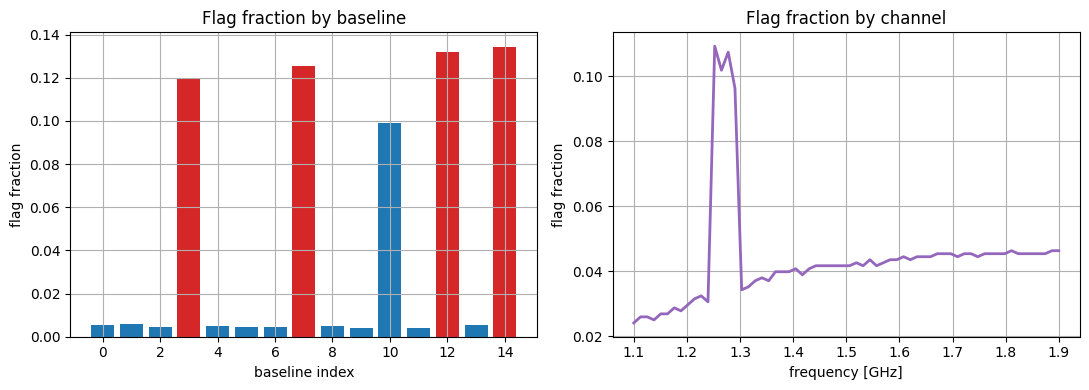

In [5]:
median_per_baseline = np.median(amp, axis=(0, 2))
mad_per_baseline = np.median(np.abs(amp - median_per_baseline[None, :, None]), axis=(0, 2)) + 1e-6

rfi_like = amp > (median_per_baseline[None, :, None] + 7.0 * mad_per_baseline[None, :, None])
low_gain_like = amp < (0.45 * median_per_baseline[None, :, None])
flag_mask = rfi_like | low_gain_like

flag_fraction_by_baseline = flag_mask.mean(axis=(0, 2))
top_baselines = np.argsort(flag_fraction_by_baseline)[::-1][:4]
channel_flag_fraction = flag_mask.mean(axis=(0, 1))
strongest_channels = np.argsort(channel_flag_fraction)[::-1][:6]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
axes[0].bar(
    np.arange(len(ms["pairs"])),
    flag_fraction_by_baseline,
    color=["tab:red" if idx in top_baselines else "tab:blue" for idx in range(len(ms["pairs"]))],
)
axes[0].set_xlabel("baseline index")
axes[0].set_ylabel("flag fraction")
axes[0].set_title("Flag fraction by baseline")

axes[1].plot(ms["freqs_ghz"], channel_flag_fraction, color="tab:purple", lw=2.0)
axes[1].set_xlabel("frequency [GHz]")
axes[1].set_ylabel("flag fraction")
axes[1].set_title("Flag fraction by channel")
plt.tight_layout()

print("最可疑的基线：")
for idx in top_baselines:
    print(f"  baseline {idx:02d} {ms['pairs'][idx]} -> flag fraction {flag_fraction_by_baseline[idx]:.3f}")

print("最可疑的通道：")
for idx in strongest_channels:
    print(f"  channel {idx:02d} ({ms['freqs_ghz'][idx]:.3f} GHz) -> flag fraction {channel_flag_fraction[idx]:.3f}")


### 9.1.4 与真实软件流程的对应

如果把上面的 notebook 练习映射到 CASA 之类的软件环境，这一节最接近下面这些任务：

- `listobs`：看懂观测结构、场、频率设置和扫描；
- `plotants`：检查天线布局；
- `plotms`：检查振幅/相位随时间、频率、基线、$uv$ 距离的变化；
- `flagdata` / `flagmanager`：先做明显异常数据的标记与管理；
- `plotms` 再次检查：确认 flag 没有过度，也没有漏掉最明显的问题。

一个很重要的专业判断是：**并不是所有异常都应该立刻被删掉。** 有些结构属于可校准误差，有些才属于必须 flag 的坏数据。后面在 [9.2 基础校准流程](9_2_calibration_workflow.ipynb) 中，我们会看到这两类问题在处理链里的角色并不相同。
